In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
plt.rcParams['figure.figsize'] = [10, 8]  #por defecto las figuras se displayan 10 pulgadas de ancho y 8 de alto

}
from sklearn.metrics import mean_squared_error, mean_absolute_error   # para manejar metricas de desempeño
from sklearn.metrics import explained_variance_score  # para hacer reportes de resultados de clasificacion
from sklearn.metrics import r2_score  # para manejar matrices de confusion

In [ ]:
# Cargar dataset
dataset = "dataset_precios.csv"
df = pd.read_csv(dataset,sep=',')

# Mostrar dimensiones iniciales
print(f'Dimensiones iniciales del dataset: {df.shape}')

# Eliminar columnas irrelevantes generadas comúnmente al exportar CSVs (como índices sin nombre)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

# Mostrar primeras filas
df.head()

Dimensiones iniciales del dataset: (16010, 3)


,Fecha,precio_promedio_kg,variedad
0,2022-01-01,1.90,Papa Amarilla
1,2022-01-01,1.08,Papa Blanca
2,2022-01-01,1.03,Papa Canchan
3,2022-01-01,1.07,Papa Color
4,2022-01-01,1.38,Papa Huamantanga


In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df = df.drop_duplicates()

In [ ]:
print(df.isnull().sum())

Fecha                 0
precio_promedio_kg    0
variedad              0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16010 entries, 0 to 16009
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Fecha               16010 non-null  object 
 1   precio_promedio_kg  16010 non-null  float64
 2   variedad            16010 non-null  object 
dtypes: float64(1), object(2)
memory usage: 375.4+ KB


In [ ]:
df = df.dropna()

In [ ]:
print(df.isnull().sum())

Fecha                 0
precio_promedio_kg    0
variedad              0
dtype: int64


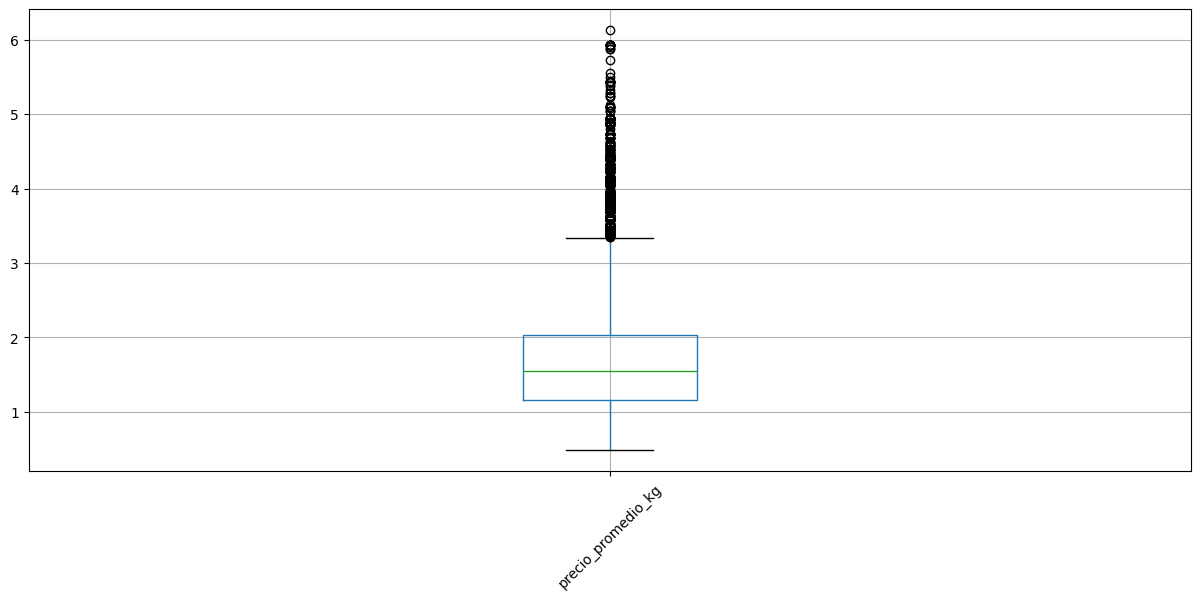

In [ ]:
numeric_cols  = df.select_dtypes(include = 'number').columns

df[numeric_cols].boxplot(figsize=(15,6))
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
precio_promedio_kg,16010.0,1.696036,0.757736,0.48,1.16,1.55,2.03,6.13


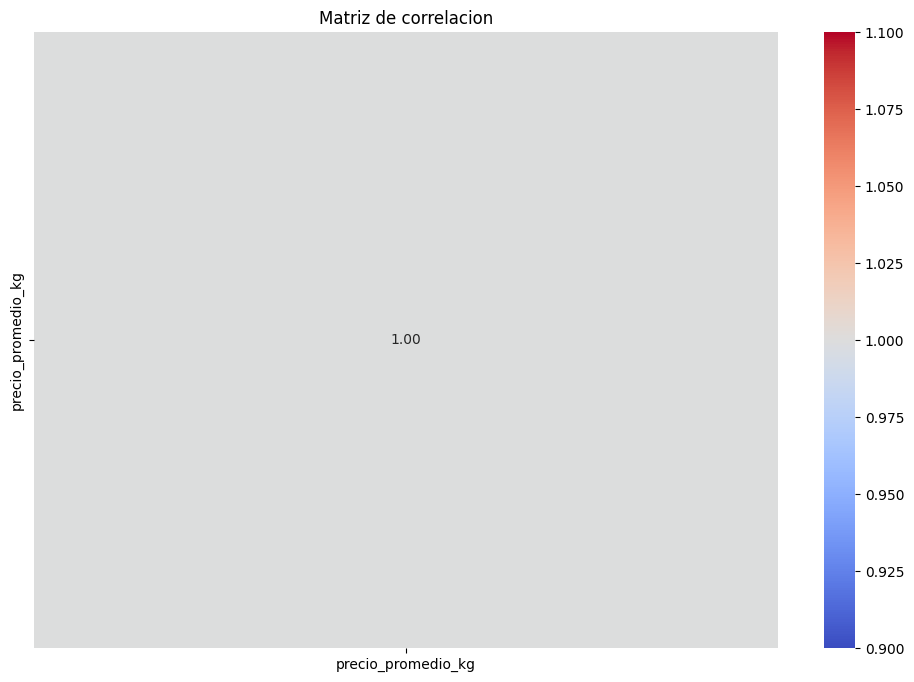

In [ ]:
numeric_df = df.select_dtypes(include='number')
corr_matrix = numeric_df.corr()

plt.figure(figsize = (12,8))
sns.heatmap(
    corr_matrix,
    annot = True,
    cmap = 'coolwarm',
    fmt = '.2f'
)

plt.title('Matriz de correlacion')
plt.show()

In [ ]:
#Guardar Archivo


df.to_csv(
    "dataset_preprocesado_precios.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Dataset guardado correctamente")

Dataset guardado correctamente
